In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

# Robert Swain

In [2]:
sample_size = 100
eligible_population = make_array(0.26, 0.74)

In [5]:
sample_proportions(sample_size, eligible_population)

array([ 0.13,  0.87])

In [14]:
def one_simulated_count():
    return sample_size * sample_proportions(sample_size, eligible_population).item(0)

In [18]:
one_simulated_count()

19.0

In [19]:
# Crushed ICE: create an array called counts and add 10,000 simulated counts to it
counts = make_array()
repetitions = 10000
for i in np.arange(repetitions):
    counts = np.append(counts, one_simulated_count())

In [23]:
counts

array([ 29.,  24.,  23., ...,  28.,  32.,  32.])

In [27]:
Table().with_column('Counts in a random sample', counts).sort(0)

Counts in a random sample
11
12
12
13
14
14
14
14
14
14


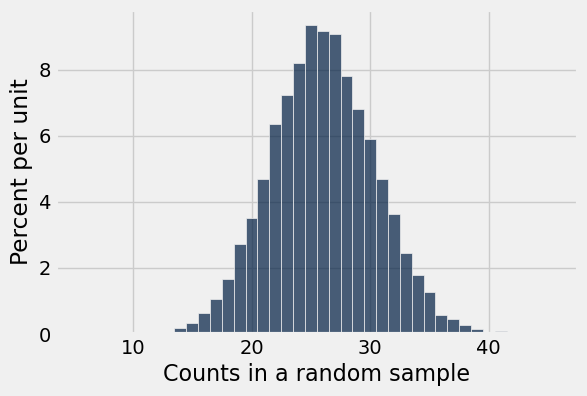

In [29]:
Table().with_column(
    'Counts in a random sample', counts
).hist(bins = np.arange(5.5, 46.5, 1))

In [32]:
np.count_nonzero(counts == 8)

0

In [33]:
np.count_nonzero(counts <= 8)

0

# Jury selection in Alameda county

In [34]:
jury = Table().with_columns(
    'Ethnicity', make_array('Asian/PI', 'Black/AA', 'Caucasian', 'Hispanic', 'Other'),
    'Eligible', make_array(0.15, 0.18, 0.54, 0.12, 0.01),
    'Panels', make_array(0.26, 0.08, 0.54, 0.08, 0.04)
)
jury

Ethnicity,Eligible,Panels
Asian/PI,0.15,0.26
Black/AA,0.18,0.08
Caucasian,0.54,0.54
Hispanic,0.12,0.08
Other,0.01,0.04


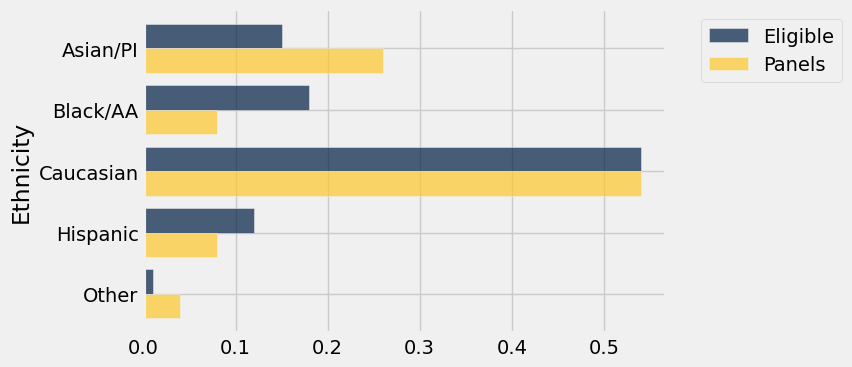

In [35]:
jury.barh('Ethnicity')

In [36]:
# Crushed ICE: There were 1,453 people on juries during the study.
# Using the proportions of eligible jurors and sample_proportions, simulate picking 1,453 jurors
jury.column('Eligible')

array([ 0.15,  0.18,  0.54,  0.12,  0.01])

In [39]:
model = jury.column('Eligible')
simulated = sample_proportions(1453, model)
simulated

array([ 0.13764625,  0.1982106 ,  0.53819683,  0.11562285,  0.01032347])

In [41]:
jury_with_simulated = jury.with_column('Simulated', simulated)
jury_with_simulated

Ethnicity,Eligible,Panels,Simulated
Asian/PI,0.15,0.26,0.137646
Black/AA,0.18,0.08,0.198211
Caucasian,0.54,0.54,0.538197
Hispanic,0.12,0.08,0.115623
Other,0.01,0.04,0.0103235


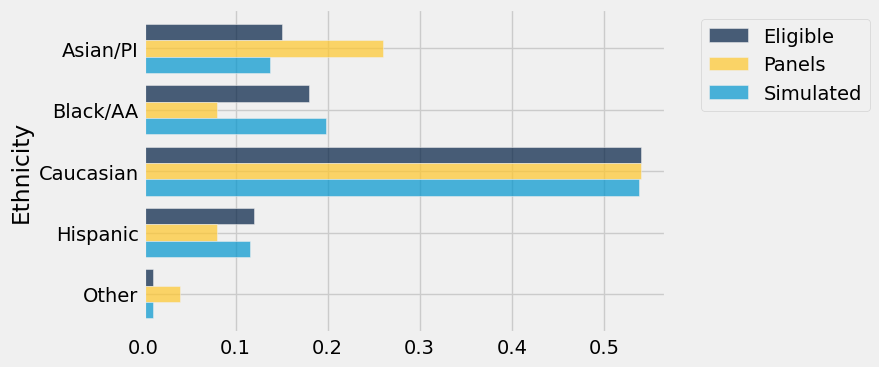

In [42]:
jury_with_simulated.barh('Ethnicity')

In [43]:
# There aren't just two things to compare! Goal: make *one number* to represent the differences
# We need a new statistic to measure the difference between the distributions!

In [44]:
jury

Ethnicity,Eligible,Panels
Asian/PI,0.15,0.26
Black/AA,0.18,0.08
Caucasian,0.54,0.54
Hispanic,0.12,0.08
Other,0.01,0.04


In [46]:
diffs = jury.column('Panels') - jury.column('Eligible')
jury_with_difference = jury.with_column('Difference', diffs)
jury_with_difference

Ethnicity,Eligible,Panels,Difference
Asian/PI,0.15,0.26,0.11
Black/AA,0.18,0.08,-0.1
Caucasian,0.54,0.54,0
Hispanic,0.12,0.08,-0.04
Other,0.01,0.04,0.03


In [48]:
sum(jury_with_difference.where('Difference', are.above(0)).column('Difference'))

0.14000000000000001

In [51]:
sum(abs(jury_with_difference.column('Difference'))) / 2

0.14000000000000001

In [54]:
def tvd(dist1, dist2):
    return sum(abs(dist1 - dist2)) / 2

In [56]:
observed_tvd = tvd(jury.column('Panels'), jury.column('Eligible'))
observed_tvd

0.14000000000000001

In [59]:
tvd(sample_proportions(1453, model), jury.column('Eligible'))

0.0065244322092222863

In [65]:
def simulated_tvd():
    return tvd(sample_proportions(1453, model), jury.column('Eligible'))

tvds = make_array()

# Crushed ICE: simluate 10,000 tvds into the tvds array
num_simulations = 10000
for i in np.arange(num_simulations):
    new_tvd = simulated_tvd()
    tvds = np.append(tvds, new_tvd)

In [67]:
len(tvds)

10000

In [68]:
tvds

array([ 0.01455609,  0.01960771,  0.01264969, ...,  0.02476256,
        0.03039229,  0.01296628])

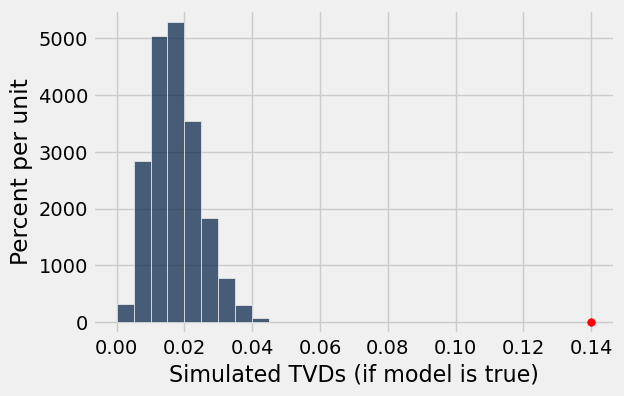

In [75]:
title = 'Simulated TVDs (if model is true)'
bins = np.arange(0, 0.05, 0.005)

Table().with_column(title, tvds).hist(bins=bins)

# Plotting the observed TVD--ignore this code!
plt.ylim(-2, 55)
plt.scatter(observed_tvd, 0, color='red', s=30);

In [77]:
np.count_nonzero(tvds >= 0.14)

0